## 1. XGBoost 개념 및 동작 원리

**XGBoost(Xtreme Gradient Boosting)**란?

Gradient Boosting 알고리즘을 더 빠르고, 더 강력하고, 과적합에 강하게 만든 알고리즘.

데이터 분석 및 캐글 대회에서 가장 많이 사용되는 기법 중 하나.

결정트리(Decision Tree)를 **Weak Learner(약한 학습기)**로 사용하여 여러 개의 트리를 순차적으로 학습시켜 성능을 높임.

XGBoost 핵심 특징
1) Boosting 방식

하나의 트리를 학습한 후 다음 트리는 이전 트리의 오차를 보완하는 방향으로 학습

즉, "틀린 부분을 계속 보완하며 강한 모델" 생성

2) Gradient Boosting 기반

각 반복(iteration)에서 Loss Function(오차)을 줄이도록 Gradient 값을 사용해 트리가 생성됨.

3) 규제(Regularization) 포함

기존 GradientBoosting과 달리 L1, L2 규제를 포함

→ 과적합(Overfitting)을 방지하는 효과

4) 분산 처리 + 빠른 연산

자체적인 최적화(병렬 처리, sparsity 대응 등)로 학습 속도가 매우 빠름

5) Early Stopping 지원

검증셋의 성능이 일정 rounds 동안 좋아지지 않으면 학습 자동 종료
→ 시간 절약 + 과적합 방지

XGBoost의 동작 과정 요약

첫 번째 트리가 데이터 패턴을 학습

예측 오류(residual error = 실제 - 예측)를 계산

두 번째 트리는 이 오류를 줄이도록 학습

계속 반복하며 트리가 추가됨

모든 트리의 예측값을 합쳐 최종 예측
→ 약한 트리들이 모여 강한 예측기가 됨

1. 위스콘신 유방암 데이터셋 컬럼 설명

이 데이터는 종양의 세포 핵(nucleus) 모양을 여러 지표로 표현한 것입니다.
각 feature는 다음 10개의 기본 값에 대해,

mean : 평균값

error : 표준오차(측정값의 변동성)

worst : 가장 안 좋은(최대) 값 근처의 평균

을 저장해놨다고 보면 됩니다.

| 컬럼명                        | 의미                           | 쉽게 설명                               |
| -------------------------- | ---------------------------- | ----------------------------------- |
| **mean radius**            | 세포 핵 반지름의 평균                 | 종양 이미지를 봤을 때 **세포 핵 크기의 평균 반경**     |
| **mean texture**           | 그레이스케일 값의 표준편차(질감) 평균        | 밝기 다양성 → **표면 질감의 거칠기/불균일성의 평균**    |
| **mean perimeter**         | 둘레 길이 평균                     | 세포 핵의 **경계 선 길이 평균**                |
| **mean area**              | 면적 평균                        | 세포 핵이 차지하는 **면적의 평균 크기**            |
| **mean smoothness**        | 반지름 길이 변화 정도 평균              | 경계가 **얼마나 매끈한지(=거칠지 않은지)** 평균       |
| **mean compactness**       | (perimeter² / area - 1.0) 평균 | **얼마나 조밀한지/둥근지**를 나타내는 값            |
| **mean concavity**         | 오목한 부분의 심각도 평균               | 경계가 **안쪽으로 파인 정도의 평균**              |
| **mean concave points**    | 오목한 부분의 개수 평균                | 경계가 **안쪽으로 꺾인 지점의 개수 평균**           |
| **mean symmetry**          | 대칭성 평균                       | 세포 모양이 **얼마나 좌우로 대칭적인지** 평균         |
| **mean fractal dimension** | 프랙탈 차원 평균                    | 경계의 복잡도, **“해안선 길이”처럼 복잡할수록 커지는 값** |


| 컬럼명                         | 의미              |
| --------------------------- | --------------- |
| **radius error**            | 반지름 값의 표준오차     |
| **texture error**           | 질감 값의 표준오차      |
| **perimeter error**         | 둘레 값의 표준오차      |
| **area error**              | 면적 값의 표준오차      |
| **smoothness error**        | 매끄러움 값의 표준오차    |
| **compactness error**       | 조밀도 값의 표준오차     |
| **concavity error**         | 오목함 심각도 값의 표준오차 |
| **concave points error**    | 오목 지점 개수의 표준오차  |
| **symmetry error**          | 대칭성 값의 표준오차     |
| **fractal dimension error** | 프랙탈 차원 값의 표준오차  |

| 컬럼명                         | 의미                                |
| --------------------------- | --------------------------------- |
| **worst radius**            | 가장 큰 반지름 값들에서 뽑은 평균 (최악에 가까운 반지름) |
| **worst texture**           | 가장 심한 질감(표준편차) 값들의 평균             |
| **worst perimeter**         | 가장 큰 둘레 값들의 평균                    |
| **worst area**              | 가장 큰 면적 값들의 평균                    |
| **worst smoothness**        | 가장 덜 매끄러운 상태의 평균                  |
| **worst compactness**       | 가장 조밀한(또는 비정상적인) 상태의 평균           |
| **worst concavity**         | 가장 심하게 오목한 상태의 평균                 |
| **worst concave points**    | 가장 오목한 지점이 많은 상태의 평균              |
| **worst symmetry**          | 가장 비대칭적인 상태의 평균                   |
| **worst fractal dimension** | 가장 복잡한 경계 상태의 평균                  |


➡ 요약하면:

mean 계열: 종양 전체의 전반적인 특징

error 계열: 값의 변동성 (안정적인지, 들쭉날쭉한지)

worst 계열: 가장 안 좋은 쪽 특성 (악성 판별에 특히 중요)

In [1]:
import xgboost
print(xgboost.__version__)

1.7.6


In [2]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 유방암 데이터셋을 불러오기
dataset = load_breast_cancer()
X_features = dataset.data                      # 가져온 데이터셋에서 입력 변수(feature)
y_label = dataset.target                       # 정답 레이블 (타겟 : 악성/양성) label 변수에 저장

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)

cancer_df['target'] = y_label

cancer_df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [4]:
print(dataset.target_names)                            # 데이터셋이 어떤 레이블을 사용하는지 출력해서 확인 (malignant: 악성(0), benign : 양성(1)) 
print(cancer_df['target'].value_counts())              # 0과 1이 각각 몇 개 있는 출력해서 데이터 분포를 확인

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [5]:
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

In [6]:
y_label

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [7]:
# 전체 데이터에서 학습 80%, 테스트 20% 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156
)

# 전체 데이터에서 90%, 테스트 10% 비율로 분리하고 모델 튜닝시 활용
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156
)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [8]:
# xgboost가 계산을 최적화하기 위해 사용되는 DMatrix 구조로 학습 데이터를 변환
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)     

In [9]:
# 모델 학습에 필요한 하이퍼파라미터 설정
params = {
    'mmax_depth' : 3,   # 트리의 깊이를 3개로 제한하여 과적합 방지
    'eta' : 0.5,        # learning rate를 설정하여 한번의 학습 단계에서 조정되는 크기 설정 
    'objective' : 'binary:logistic',     # 이진 분류 문제이므로 로지스틱 함수 사용해서 확률 예측
    'eval_metric' : 'logloss'            # 평가 지표로서, 로그손실을 사용
}

num_rounds = 400                         # 최대 boosting 반복 횟수 

In [10]:
eval_list = [(dtr, 'train'), (dval, 'eval')]

xgb_model = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_rounds,
    early_stopping_rounds=50,                 # 학습시, 평가할 데이터를 지정해서 학습과정에서 early stopping에 활용하여 조기 종료 수행
    evals=eval_list
)

[16:54:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "mmax_depth" } are not used.

[0]	train-logloss:0.35344	eval-logloss:0.44753
[1]	train-logloss:0.21460	eval-logloss:0.37983
[2]	train-logloss:0.13716	eval-logloss:0.32292
[3]	train-logloss:0.09249	eval-logloss:0.29601
[4]	train-logloss:0.06780	eval-logloss:0.29308
[5]	train-logloss:0.05213	eval-logloss:0.30020
[6]	train-logloss:0.04209	eval-logloss:0.30529
[7]	train-logloss:0.03220	eval-logloss:0.28082
[8]	train-logloss:0.02624	eval-logloss:0.28761
[9]	train-logloss:0.02161	eval-logloss:0.28909
[10]	train-logloss:0.01826	eval-logloss:0.28755
[11]	train-logloss:0.01617	eval-logloss:0.29610
[12]	train-logloss:0.01488	eval-logloss:0.29511
[13]	train-logloss:0.01367	eval-logloss:0.29838
[14]	train-logloss:0.01254	eval-logloss:0.29677
[15]	train-logloss:0.01189	eval-logloss:0.28983
[16]	train-logloss:0.01116	eval-logloss:0.

In [11]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값 출력
pred_probs = xgb_model.predict(dtest)

# 예측한 확률값 중에서 처음 10개만 출력하여 예측 결과의 값을 확인
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시')
print(np.round(pred_probs[:10], 3))

# 예측된 확률값이 0.5보다 크면 양성(1), 그렇지 않으면 악성(0)으로 판단
preds = [1 if x > 0.5 else 0 for x in pred_probs]

print("예측값 10개만 표시 : ", preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시
[0.985 0.006 0.67  0.044 0.978 1.    1.    0.999 0.998 0.   ]
예측값 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [12]:
# 행렬과 정확도 계산을 위한 지표를 가져옴
from sklearn.metrics import confusion_matrix, accuracy_score  
from sklearn. metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)                 # 모델의 예측 결과가 실제 정답과 얼마나 일치하는지 행렬로 계산
    accuracy = accuracy_score(y_test, pred)                    # 전체 예측 중 얼마나 맞췄는지를 나타내는 정확도를 계산
    precision = precision_score(y_test, pred)                  # 양성이라고 예측한 것 중에서 실제로 양성이 얼마나 되는지 정밀도를 계산
    recall = recall_score(y_test, pred)                        # 실제 양성 중에서 얼마나 맞게 맞추었는지 나타내는 재현율을 계산
    f1 = f1_score(y_test, pred)                                # 정밀도와 재현율의 조화 평균으로 f1 score를 계산
    roc_auc = roc_auc_score(y_test, pred)                      # roc 곡선 아래 면적을 의미, auc 값은 예측의 신뢰성을 평가

    print('오차행렬')
    print(confusion)

    print('정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}, \
    F1 : {3:.4f}, AUC : {4:.4f}'.format(
        accuracy, precision, recall, f1, roc_auc
    ))

get_clf_eval(y_test, preds, pred_probs)   # 위 성능 평가 함수를 호출해서 모델의 전체 성능을 확인



오차행렬
[[34  3]
 [ 4 73]]
정확도 : 0.9386, 정밀도 : 0.9605, 재현율 : 0.9481,     F1 : 0.9542, AUC : 0.9335


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

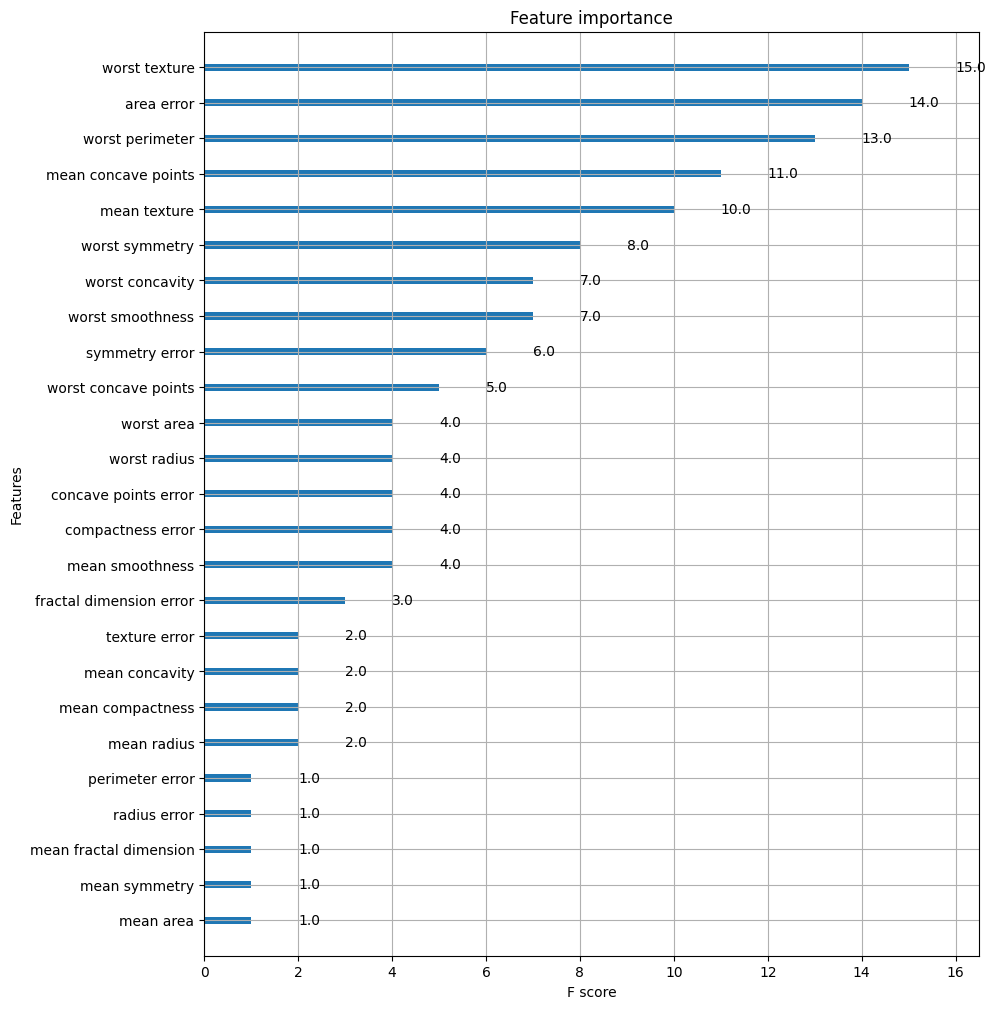

In [13]:
%matplotlib inline

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,12))
# XGBoost 모델이 학습 중 어떤 feature를 많이 사용했는지 시각적으로 표현
# --> XGBoost가 학습하면서 양성/악성에 어떤 feature가 분류에 가장 기여했는지를 보여줌

plot_importance(xgb_model, ax=ax)

In [18]:
! pip install --upgrade shap==0.41.0

In [19]:
# SHAP 라이브러리 가져오기
import shap     # SHAP은 각 feature 예측에 얼마나 기여했는지를 정량적으로 계산해주는 도구이다.
shap.__version__

shap.initjs()   # 시각화를 웹기반으로 직관적으로 표현

AttributeError: module 'numpy' has no attribute 'bool8'

In [33]:
# TreeExplainer 생성
#xgb_model = XGBClassifier()
#xgb_model.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb_model) # 이 explainer는 학습된 xgb_model을 분석해서 각 feature의 SHAP value를 계산


NameError: name 'XGBClassifier' is not defined

In [ ]:
# SHAP으로 해석에 사용할 입력 데이터
X_test_sample = X_test.copy()
X_test_sample

In [ ]:
# SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)  # 각 feature가 예측한 값에 기여한 정도의 정량적 값을 담고 있다

# 이진 분류의 경우는 shap value가 리스트 형태로 반환되는 경우가 있다. (버전에 따라서 차이 존재)
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
else:
    shap_values_to_use = shap_values  # 배열 형태로 받아오면 그대로 사용


In [ ]:
# 시각화
shap.summary_plot(
    shap_values_to_use,   # 각 샘플 피처에 대한 shap 값
    X_test_sample,        # 원본 입력 데이터
    plot_type="dot"       # 도트 형태의 요약 플롯
)

# summary_plot : x축은 SHAP 값(양수/음수 : 예측을 증가/감소시키는 방향), y축은 feature 이름
# 색깔은 해당 feature가 원래 값이 높은지/낮은지 표시 (빨강=값 큼, 파랑=값 작은, 보라=보통)

# feature 중요도를 막대 그래프 형태로 보는 bar plot
shap.summary_plot(
    shap_values_to_use,    # SHAP 값
    X_test_sample,         # 입력 데이터
    plot_type="bar"        # bar 타입을 선택하여 평균 절대 SHAP값을 기준으로 중요도 그림 <-- SHAP 값이 클수록 모델 예측에 큰 영향을 미친다는 의미
)

# 개별 샘플 데이터에 대한 로컬 설명 - force_plot
idx = 0   #

shap.force_plot(
    explainer.expected_value,              # 기준값
    shap_values_to_use[idx, :],            # 선택한 샘플의 각 피처 별 shap 값 전달 (벡터 형태)
    X_test_sample.iloc[idx, :]             # 선택한 샘플의 원 피처 값들을 전달 (벡터 형태)
)

